In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
df=pd.read_csv(r"D:\Projects\Customer Churn\WA_Fn-UseC_-Telco-Customer-Churn.csv")

## Understanding the data

In [3]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7043 entries, 0 to 7042
Data columns (total 21 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   customerID        7043 non-null   object 
 1   gender            7043 non-null   object 
 2   SeniorCitizen     7043 non-null   int64  
 3   Partner           7043 non-null   object 
 4   Dependents        7043 non-null   object 
 5   tenure            7043 non-null   int64  
 6   PhoneService      7043 non-null   object 
 7   MultipleLines     7043 non-null   object 
 8   InternetService   7043 non-null   object 
 9   OnlineSecurity    7043 non-null   object 
 10  OnlineBackup      7043 non-null   object 
 11  DeviceProtection  7043 non-null   object 
 12  TechSupport       7043 non-null   object 
 13  StreamingTV       7043 non-null   object 
 14  StreamingMovies   7043 non-null   object 
 15  Contract          7043 non-null   object 
 16  PaperlessBilling  7043 non-null   object 


In [4]:
pd.options.display.max_columns=None

In [5]:
df.head()

,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,OnlineBackup,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,7590-VHVEG,Female,0,Yes,No,1,No,No phone service,DSL,No,Yes,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No
1,5575-GNVDE,Male,0,No,No,34,Yes,No,DSL,Yes,No,Yes,No,No,No,One year,No,Mailed check,56.95,1889.5,No
2,3668-QPYBK,Male,0,No,No,2,Yes,No,DSL,Yes,Yes,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes
3,7795-CFOCW,Male,0,No,No,45,No,No phone service,DSL,Yes,No,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,No
4,9237-HQITU,Female,0,No,No,2,Yes,No,Fiber optic,No,No,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,Yes


In [6]:
df.columns

Index(['customerID', 'gender', 'SeniorCitizen', 'Partner', 'Dependents',
       'tenure', 'PhoneService', 'MultipleLines', 'InternetService',
       'OnlineSecurity', 'OnlineBackup', 'DeviceProtection', 'TechSupport',
       'StreamingTV', 'StreamingMovies', 'Contract', 'PaperlessBilling',
       'PaymentMethod', 'MonthlyCharges', 'TotalCharges', 'Churn'],
      dtype='object')

**Categorical Columns:** -  'gender', 'Partner', 'Dependents', 'PhoneService', 'MultipleLines', 'InternetService','OnlineSecurity', 'OnlineBackup', 'DeviceProtection', 'TechSupport',
       'StreamingTV', 'StreamingMovies', 'Contract', 'PaperlessBilling','PaymentMethod', Churn data
  
**Numerical Columns:** - Senior Citizen, Tenure, Monthly Charges, Total Charges

In [7]:
for i in df.columns:
    print("Column:",i)
    print(df[i].value_counts())
    print("\n")

Column: customerID
7590-VHVEG    1
3791-LGQCY    1
6008-NAIXK    1
5956-YHHRX    1
5365-LLFYV    1
             ..
9796-MVYXX    1
2637-FKFSY    1
1552-AAGRX    1
4304-TSPVK    1
3186-AJIEK    1
Name: customerID, Length: 7043, dtype: int64


Column: gender
Male      3555
Female    3488
Name: gender, dtype: int64


Column: SeniorCitizen
0    5901
1    1142
Name: SeniorCitizen, dtype: int64


Column: Partner
No     3641
Yes    3402
Name: Partner, dtype: int64


Column: Dependents
No     4933
Yes    2110
Name: Dependents, dtype: int64


Column: tenure
1     613
72    362
2     238
3     200
4     176
     ... 
28     57
39     56
44     51
36     50
0      11
Name: tenure, Length: 73, dtype: int64


Column: PhoneService
Yes    6361
No      682
Name: PhoneService, dtype: int64


Column: MultipleLines
No                  3390
Yes                 2971
No phone service     682
Name: MultipleLines, dtype: int64


Column: InternetService
Fiber optic    3096
DSL            2421
No             15

In [9]:
df.shape

(7043, 21)

## Data Cleaning

**Target Variable- Churn** --> tells whether the customer has left within last month

### Checking for any null/missing values in the dataset

In [10]:
df.isna().sum()

customerID          0
gender              0
SeniorCitizen       0
Partner             0
Dependents          0
tenure              0
PhoneService        0
MultipleLines       0
InternetService     0
OnlineSecurity      0
OnlineBackup        0
DeviceProtection    0
TechSupport         0
StreamingTV         0
StreamingMovies     0
Contract            0
PaperlessBilling    0
PaymentMethod       0
MonthlyCharges      0
TotalCharges        0
Churn               0
dtype: int64

In [11]:
df=df.replace(r'^\s*$', np.NaN,regex=True)   
#^ → start of the string, \s → any whitespace character (space, tab, newline), * → zero or more times,$ → end of the string

In [12]:
df.isna().sum()

customerID           0
gender               0
SeniorCitizen        0
Partner              0
Dependents           0
tenure               0
PhoneService         0
MultipleLines        0
InternetService      0
OnlineSecurity       0
OnlineBackup         0
DeviceProtection     0
TechSupport          0
StreamingTV          0
StreamingMovies      0
Contract             0
PaperlessBilling     0
PaymentMethod        0
MonthlyCharges       0
TotalCharges        11
Churn                0
dtype: int64

In [13]:
df[df['TotalCharges'].isna()]

,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,OnlineBackup,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
488,4472-LVYGI,Female,0,Yes,Yes,0,No,No phone service,DSL,Yes,No,Yes,Yes,Yes,No,Two year,Yes,Bank transfer (automatic),52.55,NaN,No
753,3115-CZMZD,Male,0,No,Yes,0,Yes,No,No,No internet service,No internet service,No internet service,No internet service,No internet service,No internet service,Two year,No,Mailed check,20.25,NaN,No
936,5709-LVOEQ,Female,0,Yes,Yes,0,Yes,No,DSL,Yes,Yes,Yes,No,Yes,Yes,Two year,No,Mailed check,80.85,NaN,No
1082,4367-NUYAO,Male,0,Yes,Yes,0,Yes,Yes,No,No internet service,No internet service,No internet service,No internet service,No internet service,No internet service,Two year,No,Mailed check,25.75,NaN,No
1340,1371-DWPAZ,Female,0,Yes,Yes,0,No,No phone service,DSL,Yes,Yes,Yes,Yes,Yes,No,Two year,No,Credit card (automatic),56.05,NaN,No
3331,7644-OMVMY,Male,0,Yes,Yes,0,Yes,No,No,No internet service,No internet service,No internet service,No internet service,No internet service,No internet service,Two year,No,Mailed check,19.85,NaN,No
3826,3213-VVOLG,Male,0,Yes,Yes,0,Yes,Yes,No,No internet service,No internet service,No internet service,No internet service,No internet service,No internet service,Two year,No,Mailed check,25.35,NaN,No
4380,2520-SGTTA,Female,0,Yes,Yes,0,Yes,No,No,No internet service,No internet service,No internet service,No internet service,No internet service,No internet service,Two year,No,Mailed check,20.00,NaN,No
5218,2923-ARZLG,Male,0,Yes,Yes,0,Yes,No,No,No internet service,No internet service,No internet service,No internet service,No internet service,No internet service,One year,Yes,Mailed check,19.70,NaN,No
6670,4075-WKNIU,Female,0,Yes,Yes,0,Yes,Yes,DSL,No,Yes,Yes,Yes,Yes,No,Two year,No,Mailed check,73.35,NaN,No


In [14]:
df['TotalCharges']=df['TotalCharges'].fillna(0)
#df.loc[condition, column] = value  df.loc[df['tenure']==0, 'TotalCharges']=0

Filled null values in Total Charges with zero because the tenure is 0 in those data, meaning they have just now registered so obviously no charges

In [15]:
df.isna().sum()

customerID          0
gender              0
SeniorCitizen       0
Partner             0
Dependents          0
tenure              0
PhoneService        0
MultipleLines       0
InternetService     0
OnlineSecurity      0
OnlineBackup        0
DeviceProtection    0
TechSupport         0
StreamingTV         0
StreamingMovies     0
Contract            0
PaperlessBilling    0
PaymentMethod       0
MonthlyCharges      0
TotalCharges        0
Churn               0
dtype: int64

No missing values

### Checking for any duplicate values in the dataset

In [16]:
df.duplicated().sum()

0

No duplicate values

In [17]:
df['TotalCharges']=pd.to_numeric(df['TotalCharges'], errors='raise')

In [18]:
df['TotalCharges'].dtypes

dtype('float64')

In [19]:
cols=['gender', 'Partner', 'Dependents', 'PhoneService', 'MultipleLines', 'InternetService','OnlineSecurity', 'OnlineBackup', 'DeviceProtection', 'TechSupport',
       'StreamingTV', 'StreamingMovies', 'Contract', 'PaperlessBilling','PaymentMethod', 'Churn']
for i in cols:
    print(i)
    print(df[i].unique())

gender
['Female' 'Male']
Partner
['Yes' 'No']
Dependents
['No' 'Yes']
PhoneService
['No' 'Yes']
MultipleLines
['No phone service' 'No' 'Yes']
InternetService
['DSL' 'Fiber optic' 'No']
OnlineSecurity
['No' 'Yes' 'No internet service']
OnlineBackup
['Yes' 'No' 'No internet service']
DeviceProtection
['No' 'Yes' 'No internet service']
TechSupport
['No' 'Yes' 'No internet service']
StreamingTV
['No' 'Yes' 'No internet service']
StreamingMovies
['No' 'Yes' 'No internet service']
Contract
['Month-to-month' 'One year' 'Two year']
PaperlessBilling
['Yes' 'No']
PaymentMethod
['Electronic check' 'Mailed check' 'Bank transfer (automatic)'
 'Credit card (automatic)']
Churn
['No' 'Yes']


### Label Encoding

In [20]:
from sklearn.preprocessing import LabelEncoder
encoder_l=LabelEncoder()
df['Churn_enc']=encoder_l.fit_transform(df['Churn'])

In [21]:
df['Churn_enc'].value_counts()

0    5174
1    1869
Name: Churn_enc, dtype: int64

In [22]:
df1=df.copy()

In [23]:
df1['MultipleLines']=df1['MultipleLines'].replace('No phone service','No')

In [24]:
cols_1=['OnlineSecurity','OnlineBackup','DeviceProtection','TechSupport','StreamingTV','StreamingMovies']
for i in cols_1:
    df1[i]=df1[i].replace('No internet service', 'No')

In [25]:
for i in cols:
    print(i)
    print(df1[i].unique())

gender
['Female' 'Male']
Partner
['Yes' 'No']
Dependents
['No' 'Yes']
PhoneService
['No' 'Yes']
MultipleLines
['No' 'Yes']
InternetService
['DSL' 'Fiber optic' 'No']
OnlineSecurity
['No' 'Yes']
OnlineBackup
['Yes' 'No']
DeviceProtection
['No' 'Yes']
TechSupport
['No' 'Yes']
StreamingTV
['No' 'Yes']
StreamingMovies
['No' 'Yes']
Contract
['Month-to-month' 'One year' 'Two year']
PaperlessBilling
['Yes' 'No']
PaymentMethod
['Electronic check' 'Mailed check' 'Bank transfer (automatic)'
 'Credit card (automatic)']
Churn
['No' 'Yes']


###  One hot Encoding

In [26]:
cols_enc=['gender', 'Partner', 'Dependents', 'PhoneService', 'MultipleLines', 'InternetService','OnlineSecurity', 'OnlineBackup', 'DeviceProtection', 'TechSupport',
       'StreamingTV', 'StreamingMovies', 'Contract', 'PaperlessBilling','PaymentMethod']
df1=pd.get_dummies(df1, columns=cols_enc, drop_first=True)

In [27]:
df1.head()

,customerID,SeniorCitizen,tenure,MonthlyCharges,TotalCharges,Churn,Churn_enc,gender_Male,Partner_Yes,Dependents_Yes,PhoneService_Yes,MultipleLines_Yes,InternetService_Fiber optic,InternetService_No,OnlineSecurity_Yes,OnlineBackup_Yes,DeviceProtection_Yes,TechSupport_Yes,StreamingTV_Yes,StreamingMovies_Yes,Contract_One year,Contract_Two year,PaperlessBilling_Yes,PaymentMethod_Credit card (automatic),PaymentMethod_Electronic check,PaymentMethod_Mailed check
0,7590-VHVEG,0,1,29.85,29.85,No,0,0,1,0,0,0,0,0,0,1,0,0,0,0,0,0,1,0,1,0
1,5575-GNVDE,0,34,56.95,1889.50,No,0,1,0,0,1,0,0,0,1,0,1,0,0,0,1,0,0,0,0,1
2,3668-QPYBK,0,2,53.85,108.15,Yes,1,1,0,0,1,0,0,0,1,1,0,0,0,0,0,0,1,0,0,1
3,7795-CFOCW,0,45,42.30,1840.75,No,0,1,0,0,0,0,0,0,1,0,1,1,0,0,1,0,0,0,0,0
4,9237-HQITU,0,2,70.70,151.65,Yes,1,0,0,0,1,0,1,0,0,0,0,0,0,0,0,0,1,0,1,0


In [28]:
df.head()

,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,OnlineBackup,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn,Churn_enc
0,7590-VHVEG,Female,0,Yes,No,1,No,No phone service,DSL,No,Yes,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No,0
1,5575-GNVDE,Male,0,No,No,34,Yes,No,DSL,Yes,No,Yes,No,No,No,One year,No,Mailed check,56.95,1889.50,No,0
2,3668-QPYBK,Male,0,No,No,2,Yes,No,DSL,Yes,Yes,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes,1
3,7795-CFOCW,Male,0,No,No,45,No,No phone service,DSL,Yes,No,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,No,0
4,9237-HQITU,Female,0,No,No,2,Yes,No,Fiber optic,No,No,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,Yes,1


## EDA

In [29]:
((df['Churn']=='Yes').sum()/len(df['Churn'])).round(2)*100

27.0

27% Customers Churned

In [30]:
df1.head()

,customerID,SeniorCitizen,tenure,MonthlyCharges,TotalCharges,Churn,Churn_enc,gender_Male,Partner_Yes,Dependents_Yes,PhoneService_Yes,MultipleLines_Yes,InternetService_Fiber optic,InternetService_No,OnlineSecurity_Yes,OnlineBackup_Yes,DeviceProtection_Yes,TechSupport_Yes,StreamingTV_Yes,StreamingMovies_Yes,Contract_One year,Contract_Two year,PaperlessBilling_Yes,PaymentMethod_Credit card (automatic),PaymentMethod_Electronic check,PaymentMethod_Mailed check
0,7590-VHVEG,0,1,29.85,29.85,No,0,0,1,0,0,0,0,0,0,1,0,0,0,0,0,0,1,0,1,0
1,5575-GNVDE,0,34,56.95,1889.50,No,0,1,0,0,1,0,0,0,1,0,1,0,0,0,1,0,0,0,0,1
2,3668-QPYBK,0,2,53.85,108.15,Yes,1,1,0,0,1,0,0,0,1,1,0,0,0,0,0,0,1,0,0,1
3,7795-CFOCW,0,45,42.30,1840.75,No,0,1,0,0,0,0,0,0,1,0,1,1,0,0,1,0,0,0,0,0
4,9237-HQITU,0,2,70.70,151.65,Yes,1,0,0,0,1,0,1,0,0,0,0,0,0,0,0,0,1,0,1,0


<Axes: xlabel='Churn_enc', ylabel='count'>

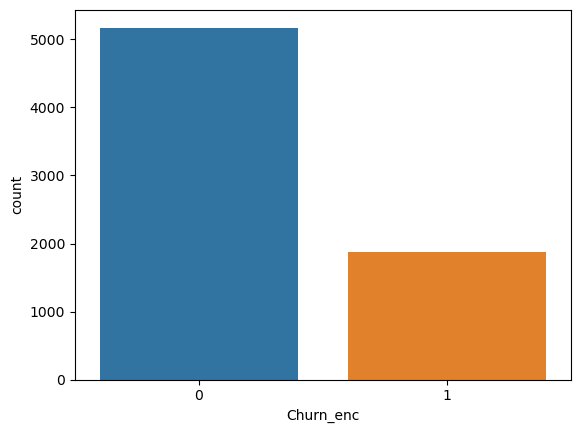

In [31]:
sns.countplot(df1,x=df1['Churn_enc'])

In [32]:
df1.to_csv(r"D:\Projects\Customer Churn\df1.csv")  #Saving the encoded file

In [2]:
df1=pd.read_csv(r"D:\Projects\Customer Churn\df1.csv")

In [3]:
df1.head()

,Unnamed: 0,customerID,SeniorCitizen,tenure,MonthlyCharges,TotalCharges,Churn,Churn_enc,gender_Male,Partner_Yes,...,DeviceProtection_Yes,TechSupport_Yes,StreamingTV_Yes,StreamingMovies_Yes,Contract_One year,Contract_Two year,PaperlessBilling_Yes,PaymentMethod_Credit card (automatic),PaymentMethod_Electronic check,PaymentMethod_Mailed check
0,0,7590-VHVEG,0,1,29.85,29.85,No,0,0,1,...,0,0,0,0,0,0,1,0,1,0
1,1,5575-GNVDE,0,34,56.95,1889.50,No,0,1,0,...,1,0,0,0,1,0,0,0,0,1
2,2,3668-QPYBK,0,2,53.85,108.15,Yes,1,1,0,...,0,0,0,0,0,0,1,0,0,1
3,3,7795-CFOCW,0,45,42.30,1840.75,No,0,1,0,...,1,1,0,0,1,0,0,0,0,0
4,4,9237-HQITU,0,2,70.70,151.65,Yes,1,0,0,...,0,0,0,0,0,0,1,0,1,0


In [9]:
df1.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7043 entries, 0 to 7042
Data columns (total 27 columns):
 #   Column                                 Non-Null Count  Dtype  
---  ------                                 --------------  -----  
 0   Unnamed: 0                             7043 non-null   int64  
 1   customerID                             7043 non-null   object 
 2   SeniorCitizen                          7043 non-null   int64  
 3   tenure                                 7043 non-null   int64  
 4   MonthlyCharges                         7043 non-null   float64
 5   TotalCharges                           7043 non-null   float64
 6   Churn                                  7043 non-null   object 
 7   Churn_enc                              7043 non-null   int64  
 8   gender_Male                            7043 non-null   int64  
 9   Partner_Yes                            7043 non-null   int64  
 10  Dependents_Yes                         7043 non-null   int64  
 11  Phon

In [4]:
df1.drop('Unnamed: 0',axis=1,inplace=True)

In [5]:
df1['Churn_enc'].value_counts()

0    5174
1    1869
Name: Churn_enc, dtype: int64

In [38]:
df.describe()

,SeniorCitizen,tenure,MonthlyCharges,TotalCharges,Churn_enc
count,7043.000000,7043.000000,7043.000000,7043.000000,7043.000000
mean,0.162147,32.371149,64.761692,2279.734304,0.265370
std,0.368612,24.559481,30.090047,2266.794470,0.441561
min,0.000000,0.000000,18.250000,0.000000,0.000000
25%,0.000000,9.000000,35.500000,398.550000,0.000000
50%,0.000000,29.000000,70.350000,1394.550000,0.000000
75%,0.000000,55.000000,89.850000,3786.600000,1.000000
max,1.000000,72.000000,118.750000,8684.800000,1.000000


###  Analysing Churn based on gender

In [39]:
pd.crosstab(df['gender'],df['Churn'])

Churn,No,Yes
gender,,
Female,2549,939
Male,2625,930


In [40]:
pd.crosstab(df['gender'],df['Churn'],normalize='index').round(2)*100

Churn,No,Yes
gender,,
Female,73.0,27.0
Male,74.0,26.0


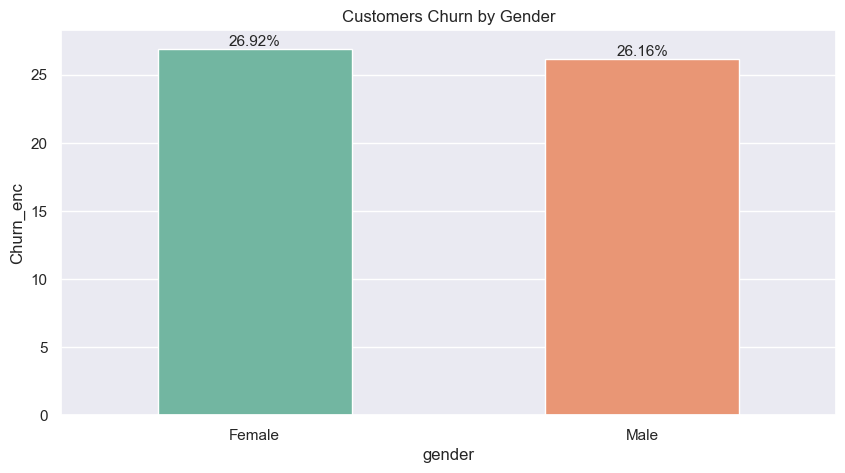

In [41]:
plt.figure(figsize=(10,5))
sns.set_theme(palette= 'Set2')
ax=sns.barplot(data=df, x=df['gender'], y=df['Churn_enc']*100,estimator='mean', errorbar=None, width=0.5)
plt.title("Customers Churn by Gender")
for i in ax.containers:
    ax.bar_label(i, fontsize=11,fmt='%.2f%%')

Churn rate is same among females (26.92%) and  males (26.16%),hence the difference is not substantial, suggesting gender is not a strong predictor of churn.”

### Contract Type vs Churn

In [42]:
df['Contract'].value_counts()

Month-to-month    3875
Two year          1695
One year          1473
Name: Contract, dtype: int64

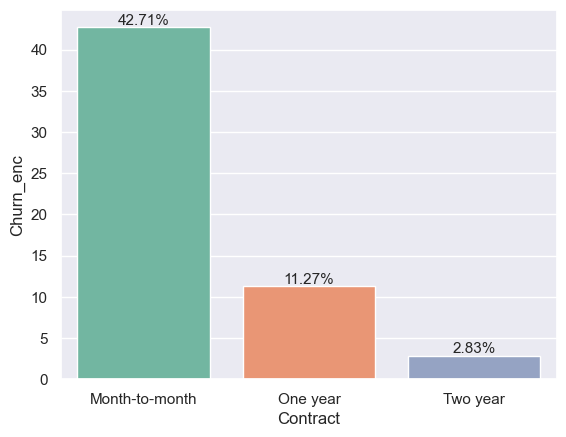

In [43]:
ax=sns.barplot(data=df, x=df['Contract'],y=df['Churn_enc']*100,estimator='mean',errorbar=None)
for i in ax.containers:
    ax.bar_label(i, fontsize=11, fmt='%0.2f%%')

Customers with month-to-month contracts:

1. Have low commitment
2. Can leave anytime
3. More sensitive to price/service issues

Customers with long-term contracts:

1. More stable
2. Less likely to churn

Customers on month-to-month contracts exhibit significantly higher churn rates, indicating low customer commitment. Long-term contracts act as a strong retention factor.

### Internet Service vs Churn

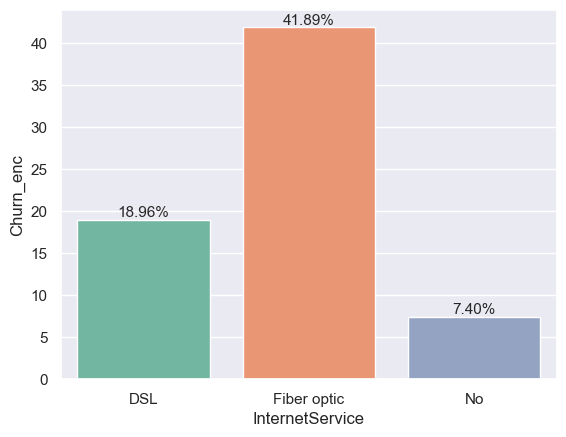

In [44]:
ax=sns.barplot(data=df, x=df['InternetService'],y=df['Churn_enc']*100,estimator='mean',errorbar=None)
for i in ax.containers:
    ax.bar_label(i, fontsize=11, fmt='%0.2f%%')

Customers using fiber optic internet show significantly higher churn rates compared to DSL and non-internet users, possibly due to higher pricing and service expectations

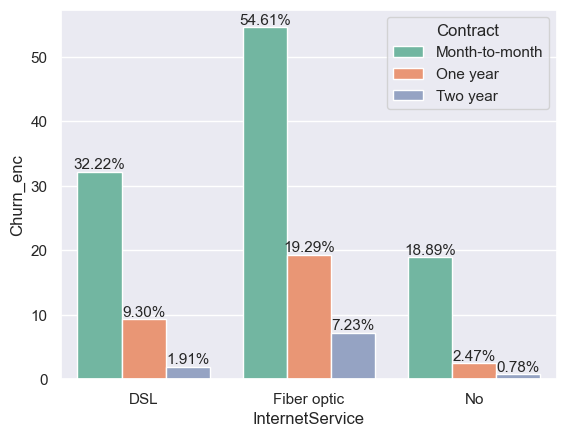

In [45]:
ax=sns.barplot(data=df, x=df['InternetService'],y=df['Churn_enc']*100,hue=df['Contract'],estimator='mean',errorbar=None)
for i in ax.containers:
    ax.bar_label(i, fontsize=11, fmt='%0.2f%%')

Customers using fiber optic internet on month-to-month contracts represent the highest-risk churn segment, combining high service cost with low contractual commitment.

### Churn based on Payment method 

In [46]:
pd.crosstab(df['PaymentMethod'],df['Churn'], normalize='index').round(2)*100

Churn,No,Yes
PaymentMethod,,
Bank transfer (automatic),83.0,17.0
Credit card (automatic),85.0,15.0
Electronic check,55.0,45.0
Mailed check,81.0,19.0


Customers using electronic check exhibit the highest churn rates, suggesting that less automated payment methods may be associated with lower customer retention

Text(0.5, 1.0, 'Average tenure by Churn')

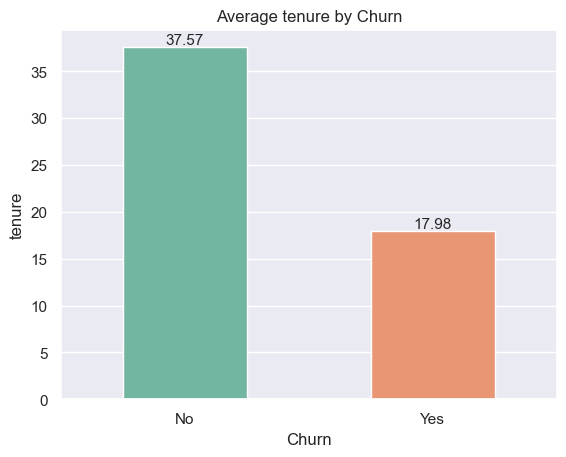

In [47]:
ax=sns.barplot(data=df, x=df['Churn'], y=df['tenure'], errorbar=None, width=0.5)
for i in ax.containers:
    ax.bar_label(i, fontsize=11, fmt='%0.2f')
plt.title("Average tenure by Churn")

<Axes: xlabel='Churn', ylabel='tenure'>

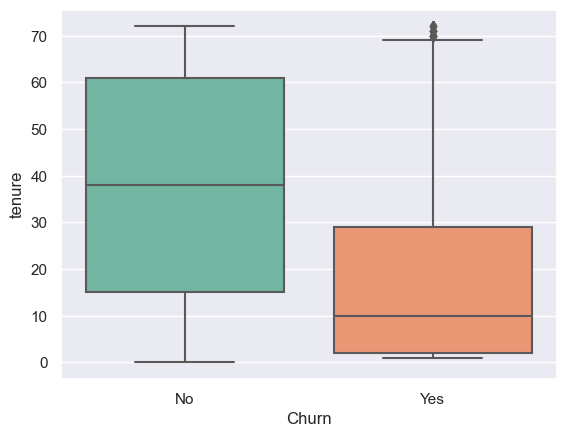

In [48]:
sns.boxplot(data=df,x=df['Churn'],y=df['tenure'])

Customers who churn tend to have significantly lower tenure compared to those who stay

<Axes: xlabel='Churn', ylabel='count'>

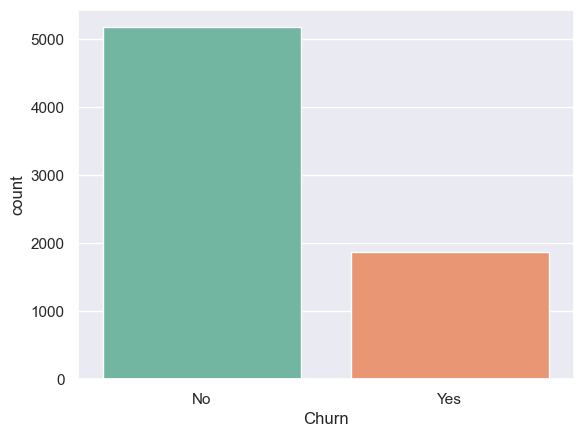

In [49]:
sns.countplot(data=df,x=df['Churn'])

In [50]:
df.groupby('Churn')['MonthlyCharges'].mean(numeric_only=True).round(2)

Churn
No     61.27
Yes    74.44
Name: MonthlyCharges, dtype: float64

Text(0.5, 1.0, 'Average Monthly charges by Churn')

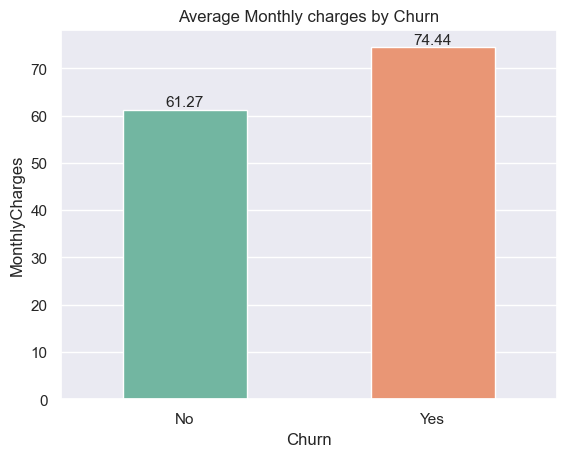

In [143]:
ax=sns.barplot(data=df, x='Churn', y='MonthlyCharges',errorbar=None, width=0.5)
for i in ax.containers:
    ax.bar_label(i, fontsize=11, fmt='%0.2f')
plt.title("Average Monthly charges by Churn")                

Customers who churn tend to have higher monthly charges, suggesting that pricing plays a significant role in customer retention

##  Data Visualisation

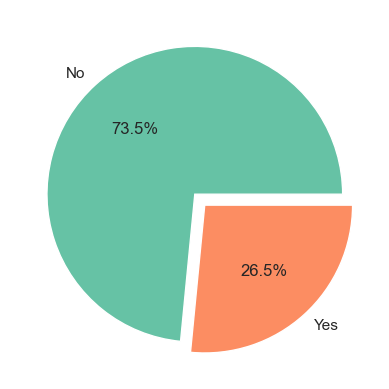

In [51]:
counts=df['Churn'].value_counts()
plt.pie(counts, labels=counts.index, autopct='%0.1f%%',explode=[0,0.1])
plt.show()

Text(0.5, 1.0, 'Churn by Tenure')

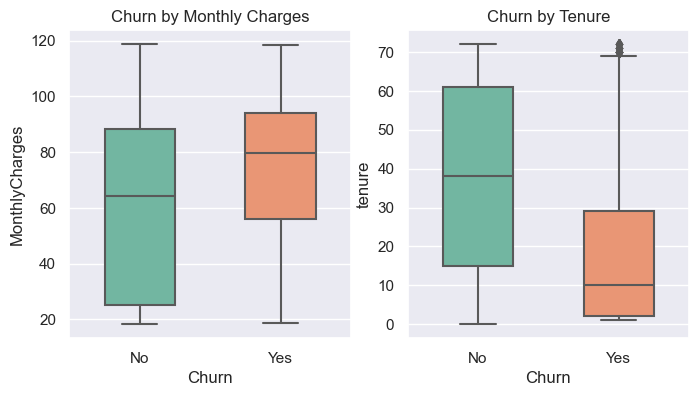

In [52]:
sns.set_theme(palette='Set2')
plt.figure(figsize=(8,4))
plt.subplot(1,2,1)
sns.boxplot(data=df, x=df['Churn'],y=df['MonthlyCharges'], width=0.5).set_title('Churn by Monthly Charges')
plt.subplot(1,2,2)
sns.boxplot(data=df, x=df['Churn'],y=df['tenure'], width=0.5).set_title('Churn by Tenure')

<Axes: xlabel='tenure', ylabel='Count'>

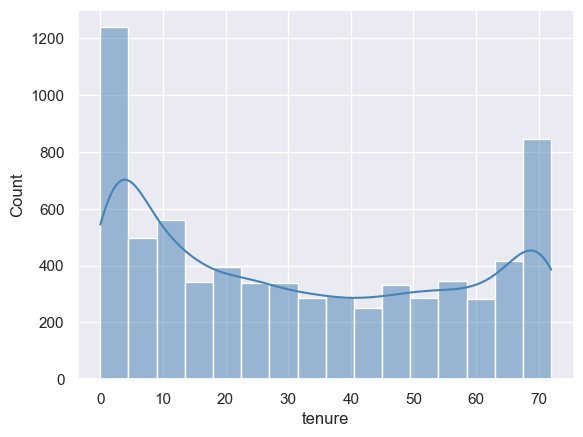

In [53]:
sns.histplot(df['tenure'],kde=True,color='steelblue')

The tenure distribution is bimodal, with peaks among new customers (0–10 months) and long-term customers (60–70 months), indicating distinct customer segments with different churn behaviors

In [54]:
df1.columns

Index(['customerID', 'SeniorCitizen', 'tenure', 'MonthlyCharges',
       'TotalCharges', 'Churn', 'Churn_enc', 'gender_Male', 'Partner_Yes',
       'Dependents_Yes', 'PhoneService_Yes', 'MultipleLines_Yes',
       'InternetService_Fiber optic', 'InternetService_No',
       'OnlineSecurity_Yes', 'OnlineBackup_Yes', 'DeviceProtection_Yes',
       'TechSupport_Yes', 'StreamingTV_Yes', 'StreamingMovies_Yes',
       'Contract_One year', 'Contract_Two year', 'PaperlessBilling_Yes',
       'PaymentMethod_Credit card (automatic)',
       'PaymentMethod_Electronic check', 'PaymentMethod_Mailed check'],
      dtype='object')

In [55]:
df1[['tenure', 'MonthlyCharges',
       'TotalCharges', 'Churn_enc']].corr()

,tenure,MonthlyCharges,TotalCharges,Churn_enc
tenure,1.000000,0.247900,0.826178,-0.352229
MonthlyCharges,0.247900,1.000000,0.651174,0.193356
TotalCharges,0.826178,0.651174,1.000000,-0.198324
Churn_enc,-0.352229,0.193356,-0.198324,1.000000


<Axes: >

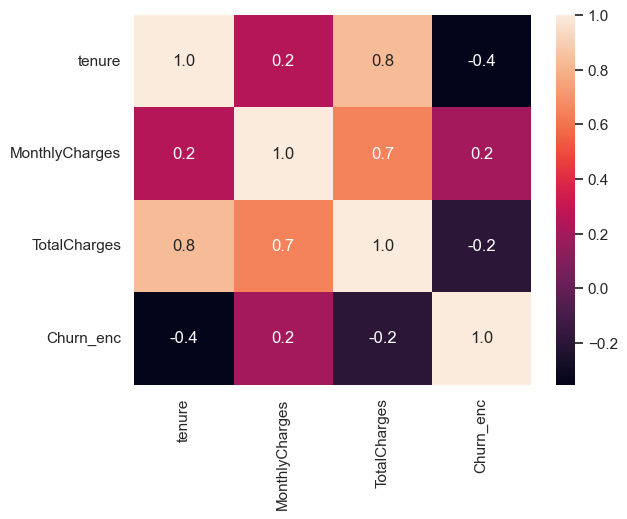

In [56]:
sns.heatmap(df1[['tenure', 'MonthlyCharges',
       'TotalCharges', 'Churn_enc']].corr(), annot=True, fmt='0.1f')

Tenure and Total Charges are highly correlated and Churn in negatively correlated with tenure

Tenure shows the strongest negative correlation with churn, indicating that customers with longer tenure are less likely to churn.

“Monthly charges have a weak positive correlation with churn, suggesting that higher pricing slightly increases churn risk.”

“Total charges are highly correlated with tenure, indicating potential multicollinearity between these features.

In [57]:
pd.crosstab(df['Contract'],df['Churn_enc'],normalize='index').round(2)*100

Churn_enc,0,1
Contract,,
Month-to-month,57.0,43.0
One year,89.0,11.0
Two year,97.0,3.0


## Feature Engineering

In [58]:
df['Average_Monthlyspend']=(df['TotalCharges']/df['tenure']).round(2)
df.head()

,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,OnlineBackup,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn,Churn_enc,Average_Monthlyspend
0,7590-VHVEG,Female,0,Yes,No,1,No,No phone service,DSL,No,Yes,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No,0,29.85
1,5575-GNVDE,Male,0,No,No,34,Yes,No,DSL,Yes,No,Yes,No,No,No,One year,No,Mailed check,56.95,1889.50,No,0,55.57
2,3668-QPYBK,Male,0,No,No,2,Yes,No,DSL,Yes,Yes,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes,1,54.08
3,7795-CFOCW,Male,0,No,No,45,No,No phone service,DSL,Yes,No,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,No,0,40.91
4,9237-HQITU,Female,0,No,No,2,Yes,No,Fiber optic,No,No,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,Yes,1,75.82


In [59]:
df.tail()

,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,OnlineBackup,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn,Churn_enc,Average_Monthlyspend
7038,6840-RESVB,Male,0,Yes,Yes,24,Yes,Yes,DSL,Yes,No,Yes,Yes,Yes,Yes,One year,Yes,Mailed check,84.80,1990.50,No,0,82.94
7039,2234-XADUH,Female,0,Yes,Yes,72,Yes,Yes,Fiber optic,No,Yes,Yes,No,Yes,Yes,One year,Yes,Credit card (automatic),103.20,7362.90,No,0,102.26
7040,4801-JZAZL,Female,0,Yes,Yes,11,No,No phone service,DSL,Yes,No,No,No,No,No,Month-to-month,Yes,Electronic check,29.60,346.45,No,0,31.50
7041,8361-LTMKD,Male,1,Yes,No,4,Yes,Yes,Fiber optic,No,No,No,No,No,No,Month-to-month,Yes,Mailed check,74.40,306.60,Yes,1,76.65
7042,3186-AJIEK,Male,0,No,No,66,Yes,No,Fiber optic,Yes,No,Yes,Yes,Yes,Yes,Two year,Yes,Bank transfer (automatic),105.65,6844.50,No,0,103.70


The difference between MonthlyCharges and AvgMonthlySpend arises because MonthlyCharges reflects the current billing amount, while AvgMonthlySpend captures historical spending, which may vary due to plan changes, discounts, or tenure length

In [60]:
(df['Average_Monthlyspend']).corr(df['MonthlyCharges'])

0.9962374413414495

ince AvgMonthlySpend is derived from TotalCharges and tenure, it is highly correlated (0.99) with MonthlyCharges. To avoid multicollinearity, I removed the redundant feature and retained MonthlyCharges

In [61]:
df.drop('Average_Monthlyspend',axis=1,inplace=True)

In [62]:
df['tenure'].describe()

count    7043.000000
mean       32.371149
std        24.559481
min         0.000000
25%         9.000000
50%        29.000000
75%        55.000000
max        72.000000
Name: tenure, dtype: float64

In [63]:
df['Tenure_Group']=pd.cut(df['tenure'],bins=[0,24,48,80], labels=['Short','Medium','Long'])
df.head()

,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,OnlineBackup,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn,Churn_enc,Tenure_Group
0,7590-VHVEG,Female,0,Yes,No,1,No,No phone service,DSL,No,Yes,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No,0,Short
1,5575-GNVDE,Male,0,No,No,34,Yes,No,DSL,Yes,No,Yes,No,No,No,One year,No,Mailed check,56.95,1889.50,No,0,Medium
2,3668-QPYBK,Male,0,No,No,2,Yes,No,DSL,Yes,Yes,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes,1,Short
3,7795-CFOCW,Male,0,No,No,45,No,No phone service,DSL,Yes,No,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,No,0,Medium
4,9237-HQITU,Female,0,No,No,2,Yes,No,Fiber optic,No,No,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,Yes,1,Short


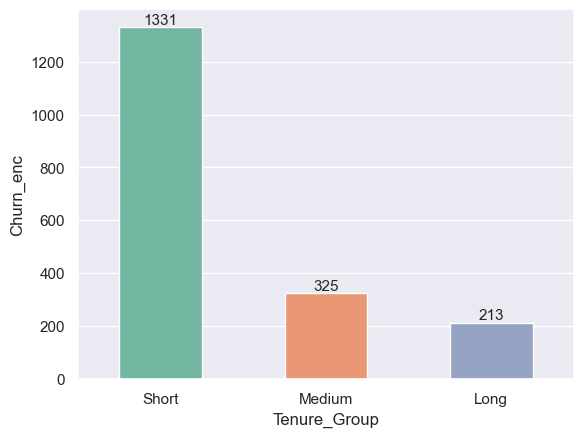

In [64]:
ax=sns.barplot(data=df, x=df['Tenure_Group'],y=df['Churn_enc'], estimator='sum',width=0.5, errorbar=None)
for i in ax.containers:
    ax.bar_label(i, fontsize=11)

Churn risk is significantly higher among customers with shorter tenure, indicating that customer attrition is most prevalent in the early stages of the customer lifecycle.

### Correlation 

In [65]:
df1.corr()['Churn_enc'].sort_values(ascending=True).round(2)

C:\Users\GAYATHRI NARESH\AppData\Local\Temp\ipykernel_8176\2482434050.py:1: FutureWarning: The default value of numeric_only in DataFrame.corr is deprecated. In a future version, it will default to False. Select only valid columns or specify the value of numeric_only to silence this warning.
  df1.corr()['Churn_enc'].sort_values(ascending=True).round(2)


tenure                                  -0.35
Contract_Two year                       -0.30
InternetService_No                      -0.23
TotalCharges                            -0.20
Contract_One year                       -0.18
OnlineSecurity_Yes                      -0.17
TechSupport_Yes                         -0.16
Dependents_Yes                          -0.16
Partner_Yes                             -0.15
PaymentMethod_Credit card (automatic)   -0.13
PaymentMethod_Mailed check              -0.09
OnlineBackup_Yes                        -0.08
DeviceProtection_Yes                    -0.07
gender_Male                             -0.01
PhoneService_Yes                         0.01
MultipleLines_Yes                        0.04
StreamingMovies_Yes                      0.06
StreamingTV_Yes                          0.06
SeniorCitizen                            0.15
PaperlessBilling_Yes                     0.19
MonthlyCharges                           0.19
PaymentMethod_Electronic check    

**Positive Correlation**

PaperlessBilling_Yes                     0.19 \
MonthlyCharges                           0.19 --> high churn risk \
PaymentMethod_Electronic check           0.30 --> less automated payment\
InternetService_Fiber optic              0.31 --> higher churn due to cost\\

**Negative Correlation**

tenure                                  -0.35 --> higher tenure, less churn rate\
Contract_Two year                       -0.30 --> long term contract, less churn\
InternetService_No                      -0.23 \
TotalCharges                            -0.20  \

#### Insights
Tenure and contract type are the strongest predictors of churn, with longer tenure and long-term contracts significantly reducing churn risk.

Customers using fiber optic internet and electronic check payment methods show the highest churn propensity.

Gender and phone service have negligible impact on churn.

###  Hypothesis Testing

In [66]:
df['Churn_enc'].value_counts()

0    5174
1    1869
Name: Churn_enc, dtype: int64

In [67]:
df['Contract'].value_counts()

Month-to-month    3875
Two year          1695
One year          1473
Name: Contract, dtype: int64

#### 1. Test: “Customers with month-to-month contracts churn more than long-term contracts.” 

**Null Hypothesis:** Churn in month to month contract and long term are same

**Alternate hypothesis:** Higher Churn in month-to-month contract than long term

Performing chi-squared test as it is categorical data

In [69]:
table=pd.crosstab(df['Contract'], df['Churn'])
print(table)

Churn             No   Yes
Contract                  
Month-to-month  2220  1655
One year        1307   166
Two year        1647    48


In [70]:
from scipy.stats import chi2_contingency

chi2, p, dof, expected = chi2_contingency(table)

print("p-value:", p)

p-value: 5.863038300673391e-258


p value < 0.05 Null hypotheses can be rejected.

There is a statistically significant association between contract type and churn. Customers with month-to-month contracts are more likely to churn.

In [73]:
pd.crosstab(df['Contract'], df['Churn'], normalize='index').round(2) * 100

Churn,No,Yes
Contract,,
Month-to-month,57.0,43.0
One year,89.0,11.0
Two year,97.0,3.0


The Chi-square test resulted in a p-value < 0.05, indicating a significant association between contract type and churn. Further analysis of churn rates shows that customers with month-to-month contracts have a higher churn rate compared to long-term contracts.

#### 2. Test: Higher monthly charges are associated with higher Churn


<Axes: xlabel='MonthlyCharges', ylabel='Density'>

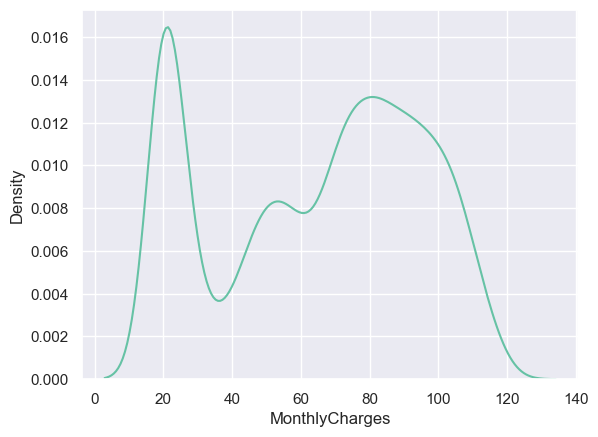

In [74]:
sns.kdeplot(df['MonthlyCharges'])

In [76]:
df.groupby('Churn').median()['MonthlyCharges']

C:\Users\GAYATHRI NARESH\AppData\Local\Temp\ipykernel_8176\2909460294.py:1: FutureWarning: The default value of numeric_only in DataFrameGroupBy.median is deprecated. In a future version, numeric_only will default to False. Either specify numeric_only or select only columns which should be valid for the function.
  df.groupby('Churn').median()['MonthlyCharges']


Churn
No     64.425
Yes    79.650
Name: MonthlyCharges, dtype: float64

In [77]:
df.groupby('Churn').mean()['MonthlyCharges']

C:\Users\GAYATHRI NARESH\AppData\Local\Temp\ipykernel_8176\2059103108.py:1: FutureWarning: The default value of numeric_only in DataFrameGroupBy.mean is deprecated. In a future version, numeric_only will default to False. Either specify numeric_only or select only columns which should be valid for the function.
  df.groupby('Churn').mean()['MonthlyCharges']


Churn
No     61.265124
Yes    74.441332
Name: MonthlyCharges, dtype: float64

**Null Hypothesis:** Median MonthlyCharges (Churn = Yes) = Median MonthlyCharges (Churn = No)

**Alternate Hypothesis:** Median MonthlyCharges (Churn = Yes) > Median MonthlyCharges (Churn = No)

In [78]:
from scipy.stats import mannwhitneyu

churn_yes = df[df['Churn'] == 'Yes']['MonthlyCharges']
churn_no = df[df['Churn'] == 'No']['MonthlyCharges']

stat, p_value = mannwhitneyu(churn_yes, churn_no)

print("p-value:", p_value)

p-value: 3.311627651988585e-54


Since MonthlyCharges exhibited a non-normal (multimodal) distribution, a Mann–Whitney U test was used instead of a t-test. The results confirmed a statistically significant difference in charges between churned and non-churned customers

<Axes: xlabel='MonthlyCharges', ylabel='Density'>

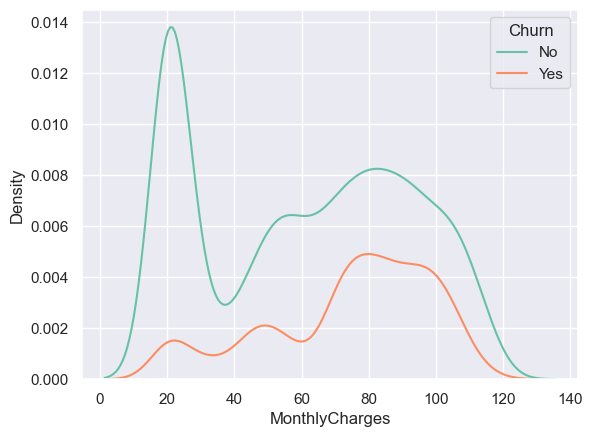

In [79]:
sns.kdeplot(data=df, x='MonthlyCharges', hue='Churn')

#### 3. Test: Tenure significantly impacts churn

**Null Hypothesis:** Churn is not associated with tenure

**AH:** Churn is significantly influenced by Tenure

<Axes: xlabel='tenure', ylabel='Density'>

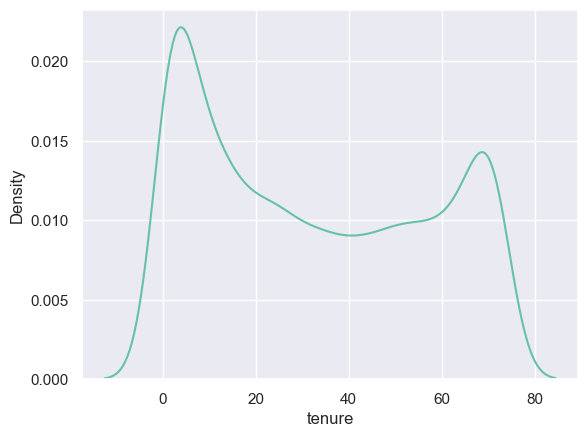

In [81]:
sns.kdeplot(df['tenure'])

In [82]:
df['tenure'].median()

29.0

In [90]:
df[df['Churn']=='Yes']['tenure'].mean().round(2)

17.98

In [92]:
df[df['Churn']=='Yes']['tenure'].median()

10.0

In [94]:
df.groupby(['Churn'])['tenure'].mean().round(2)

Churn
No     37.57
Yes    17.98
Name: tenure, dtype: float64

In [95]:
df.groupby(['Churn'])['tenure'].median().round(2)

Churn
No     38.0
Yes    10.0
Name: tenure, dtype: float64

In [96]:
from scipy.stats import mannwhitneyu

churn_yestenure=df[df['Churn']=='Yes']['tenure']
churn_notenure=df[df['Churn']=='No']['tenure']

stat,p_value=mannwhitneyu(churn_yestenure, churn_notenure)

In [97]:
p_value

2.419635517951866e-208

In [98]:
stat

2515538.0

There is a statistically significant relationship between tenure and churn. This confirms that tenure is a strong predictor of churn, with lower-tenure customers being more likely to churn.

In [99]:
n1 = len(churn_yestenure)
n2 = len(churn_notenure)

effect_size = stat / (n1 * n2)
print(effect_size)

0.26013282447137115


The effect size of 0.26 indicates a moderate difference in tenure between churned and non-churned customers, with churned customers having significantly lower tenure

### Machine Learning

In [6]:
df1.columns

Index(['customerID', 'SeniorCitizen', 'tenure', 'MonthlyCharges',
       'TotalCharges', 'Churn', 'Churn_enc', 'gender_Male', 'Partner_Yes',
       'Dependents_Yes', 'PhoneService_Yes', 'MultipleLines_Yes',
       'InternetService_Fiber optic', 'InternetService_No',
       'OnlineSecurity_Yes', 'OnlineBackup_Yes', 'DeviceProtection_Yes',
       'TechSupport_Yes', 'StreamingTV_Yes', 'StreamingMovies_Yes',
       'Contract_One year', 'Contract_Two year', 'PaperlessBilling_Yes',
       'PaymentMethod_Credit card (automatic)',
       'PaymentMethod_Electronic check', 'PaymentMethod_Mailed check'],
      dtype='object')

In [7]:
X=df1.drop(['customerID','Churn', 'Churn_enc'],axis=1)
y=df1['Churn_enc']

In [8]:
X.head()

,SeniorCitizen,tenure,MonthlyCharges,TotalCharges,gender_Male,Partner_Yes,Dependents_Yes,PhoneService_Yes,MultipleLines_Yes,InternetService_Fiber optic,...,DeviceProtection_Yes,TechSupport_Yes,StreamingTV_Yes,StreamingMovies_Yes,Contract_One year,Contract_Two year,PaperlessBilling_Yes,PaymentMethod_Credit card (automatic),PaymentMethod_Electronic check,PaymentMethod_Mailed check
0,0,1,29.85,29.85,0,1,0,0,0,0,...,0,0,0,0,0,0,1,0,1,0
1,0,34,56.95,1889.50,1,0,0,1,0,0,...,1,0,0,0,1,0,0,0,0,1
2,0,2,53.85,108.15,1,0,0,1,0,0,...,0,0,0,0,0,0,1,0,0,1
3,0,45,42.30,1840.75,1,0,0,0,0,0,...,1,1,0,0,1,0,0,0,0,0
4,0,2,70.70,151.65,0,0,0,1,0,1,...,0,0,0,0,0,0,1,0,1,0


In [9]:
y.head()

0    0
1    0
2    1
3    0
4    1
Name: Churn_enc, dtype: int64

In [10]:
X1=X.copy()
X1.head()

,SeniorCitizen,tenure,MonthlyCharges,TotalCharges,gender_Male,Partner_Yes,Dependents_Yes,PhoneService_Yes,MultipleLines_Yes,InternetService_Fiber optic,...,DeviceProtection_Yes,TechSupport_Yes,StreamingTV_Yes,StreamingMovies_Yes,Contract_One year,Contract_Two year,PaperlessBilling_Yes,PaymentMethod_Credit card (automatic),PaymentMethod_Electronic check,PaymentMethod_Mailed check
0,0,1,29.85,29.85,0,1,0,0,0,0,...,0,0,0,0,0,0,1,0,1,0
1,0,34,56.95,1889.50,1,0,0,1,0,0,...,1,0,0,0,1,0,0,0,0,1
2,0,2,53.85,108.15,1,0,0,1,0,0,...,0,0,0,0,0,0,1,0,0,1
3,0,45,42.30,1840.75,1,0,0,0,0,0,...,1,1,0,0,1,0,0,0,0,0
4,0,2,70.70,151.65,0,0,0,1,0,1,...,0,0,0,0,0,0,1,0,1,0


X1.drop(['Unnamed: 0'],axis=1,inplace=True)

In [12]:
from sklearn.model_selection import train_test_split

In [13]:
X_train_scaled,X_test_scaled,y_train,y_test=train_test_split(X1,y,test_size=0.2)

In [14]:
X_train_scaled.shape,X_test_scaled.shape,y_train.shape,y_test.shape

((5634, 23), (1409, 23), (5634,), (1409,))

In [15]:
from sklearn.preprocessing import StandardScaler
scaler=StandardScaler()

In [16]:
num_cols=['tenure','MonthlyCharges','TotalCharges']

In [17]:
scaler.fit(X_train_scaled[num_cols])

StandardScaler()

In [18]:
X_train_scaled[num_cols]=scaler.transform(X_train_scaled[num_cols])
X_test_scaled[num_cols]=scaler.transform(X_test_scaled[num_cols])

In [19]:
X_train_scaled.head()

,SeniorCitizen,tenure,MonthlyCharges,TotalCharges,gender_Male,Partner_Yes,Dependents_Yes,PhoneService_Yes,MultipleLines_Yes,InternetService_Fiber optic,...,DeviceProtection_Yes,TechSupport_Yes,StreamingTV_Yes,StreamingMovies_Yes,Contract_One year,Contract_Two year,PaperlessBilling_Yes,PaymentMethod_Credit card (automatic),PaymentMethod_Electronic check,PaymentMethod_Mailed check
1849,0,-0.908023,-0.626760,-0.823955,1,0,0,1,0,0,...,0,0,0,0,0,0,1,0,1,0
107,0,-0.010156,-1.137848,-0.591250,0,0,0,0,0,0,...,0,0,0,0,1,0,0,0,0,1
3985,1,-0.663150,-0.328072,-0.636700,1,1,0,1,0,0,...,0,0,0,0,0,0,1,0,0,0
5252,1,1.581517,1.429210,2.416299,1,1,0,1,1,1,...,1,0,1,1,0,0,1,0,1,0
4991,0,1.050960,1.394363,1.721486,0,0,0,1,0,1,...,1,0,1,1,1,0,1,0,1,0


### Building Logistic Regression Model

In [20]:
from sklearn.linear_model import LogisticRegression

In [21]:
model_LogReg=LogisticRegression()

In [22]:
model_LogReg.fit(X_train_scaled,y_train)

LogisticRegression()

In [23]:
y_pred=model_LogReg.predict(X_test_scaled)

In [24]:
model_LogReg.predict_proba(X_test_scaled) #Predicting the probabilities of test data

array([[0.79925772, 0.20074228],
       [0.78428209, 0.21571791],
       [0.31183268, 0.68816732],
       ...,
       [0.92143391, 0.07856609],
       [0.92143398, 0.07856602],
       [0.22516783, 0.77483217]])

#### Model Evaluation

In [25]:
from sklearn.metrics import confusion_matrix, accuracy_score, roc_auc_score,classification_report

In [26]:
from sklearn.metrics import precision_score, recall_score

In [27]:
cm=confusion_matrix(y_test,y_pred)
cm

array([[912, 124],
       [165, 208]], dtype=int64)

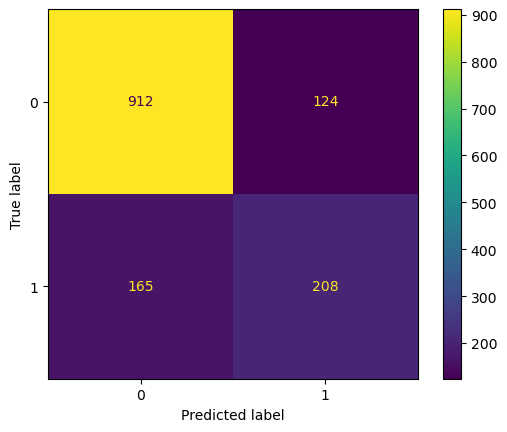

In [28]:
from sklearn.metrics import ConfusionMatrixDisplay
disp = ConfusionMatrixDisplay(confusion_matrix=cm,
                              display_labels=model_LogReg.classes_)
disp.plot()
plt.show()

In [29]:
print('Accuracy is:',accuracy_score(y_test,y_pred).round(2)*100)

Accuracy is: 79.0


In [30]:
print(classification_report(y_test,y_pred))

              precision    recall  f1-score   support

           0       0.85      0.88      0.86      1036
           1       0.63      0.56      0.59       373

    accuracy                           0.79      1409
   macro avg       0.74      0.72      0.73      1409
weighted avg       0.79      0.79      0.79      1409



In [31]:
print(roc_auc_score(y_test,y_pred))

0.7189748154895609


In [32]:
def roc_auc(y_test_predicted):
    import sklearn.metrics as metrics
# calculate the fpr and tpr for all thresholds of the classification
    fpr, tpr, threshold = metrics.roc_curve(y_test,y_test_predicted)
    roc_auc = metrics.auc(fpr, tpr)
    print('ROC-AUC value is:',roc_auc)
    plt.title('Receiver Operating Characteristic')
    plt.plot(fpr, tpr, 'b', label = 'AUC = %0.2f' % roc_auc)
    plt.legend(loc = 'lower right')
    plt.plot([0, 1], [0, 1],'r--')
    plt.xlim([0, 1])
    plt.ylim([0, 1])
    plt.ylabel('True Positive Rate')
    plt.xlabel('False Positive Rate')
    plt.show()

ROC-AUC value is: 0.7189748154895609


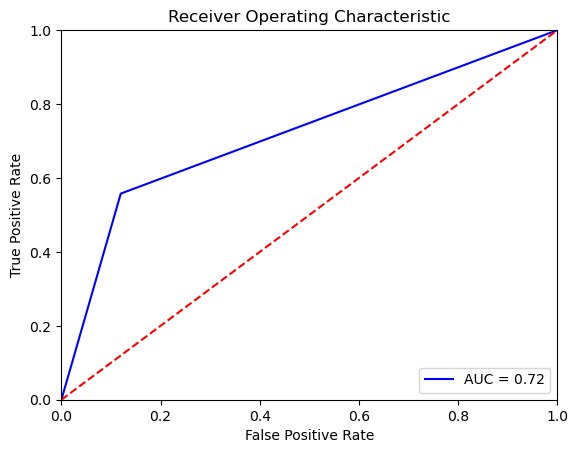

In [33]:
roc_auc(y_pred) #ROC-AUC value for Logistic Regression model

**INFERENCES**
1. Logistic Regression Model gives an accuracy of 80%.
2. Taking into account the imbalance in dataset, seeing the confusion matrix --> there are 124 False positive cases and 165 False negative
3. ROC-AUC value is 0.72 which means 72% the model classifies correctly.

165 False negative is a huge number in churn analysis as we may miss those customers easily.

## Building Decision Tree Classifier

In [34]:
X_train, X_test,y_train,y_test=train_test_split(X1,y,test_size=0.2,random_state=2)

In [35]:
X_train.shape, X_test.shape,y_train.shape,y_test.shape

((5634, 23), (1409, 23), (5634,), (1409,))

In [36]:
from sklearn.tree import DecisionTreeClassifier

In [37]:
DTC_1=DecisionTreeClassifier(criterion='entropy')

In [38]:
DTC_1.fit(X_train, y_train)

DecisionTreeClassifier(criterion='entropy')

In [39]:
y_pred_DTC=DTC_1.predict(X_test)

In [40]:
cm_DTC=confusion_matrix(y_test,y_pred_DTC)
cm_DTC

array([[872, 189],
       [176, 172]], dtype=int64)

In [41]:
print(accuracy_score(y_test,y_pred_DTC))

0.7409510290986515


In [42]:
y_train_pred_DTC=DTC_1.predict(X_train)

In [43]:
print(accuracy_score(y_train,y_train_pred_DTC))

0.9978700745473909


In [44]:
print(classification_report(y_test,y_pred_DTC))

              precision    recall  f1-score   support

           0       0.83      0.82      0.83      1061
           1       0.48      0.49      0.49       348

    accuracy                           0.74      1409
   macro avg       0.65      0.66      0.66      1409
weighted avg       0.74      0.74      0.74      1409



In [45]:
df1['Churn_enc'].value_counts()

0    5174
1    1869
Name: Churn_enc, dtype: int64

### Inference from Decision Tree Classifier

##### Training accuracy of 99% and Testing accurcay of 74% clearly shows that model is suffering from overfitting. 

It cane be due to noise learned from training data and imbalance in class.
The model can be improved using hyperparameter tuning and cross validation or ensembled learning using a Random Forest Classifier

#### Building Random Forest Classifier

In [95]:
from sklearn.ensemble import RandomForestClassifier

In [213]:
RFC=RandomForestClassifier()

In [212]:
RandomForestClassifier?

In [214]:
RFC.fit(X_train,y_train)

RandomForestClassifier()

In [215]:
y_pred_RFC=RFC.predict(X_test)

In [216]:
print(accuracy_score(y_test,y_pred_RFC))

0.7906316536550745


In [217]:
cm_RFC=confusion_matrix(y_test,y_pred_RFC)
cm_RFC

array([[926, 109],
       [186, 188]], dtype=int64)

In [218]:
print(classification_report(y_test,y_pred_RFC))

              precision    recall  f1-score   support

           0       0.83      0.89      0.86      1035
           1       0.63      0.50      0.56       374

    accuracy                           0.79      1409
   macro avg       0.73      0.70      0.71      1409
weighted avg       0.78      0.79      0.78      1409



In [219]:
print(roc_auc_score(y_test,y_pred_RFC))

0.6986798935648041


In [220]:
print(precision_score(y_test,y_pred_RFC))

0.632996632996633


In [221]:
print(recall_score(y_test,y_pred_RFC))

0.5026737967914439


Using Random Forest Classifier the accuracy, precision and recall has not significantly improved.

#### Hyperparameter Tuning and cross validation in Decision Tree Classifier

In [46]:
from sklearn.model_selection import GridSearchCV

In [57]:
DecisionTreeClassifier?

In [59]:
p_grid={'criterion':['gini','entropy'],
    'max_depth':range(2,20,2),
       'min_samples_split':range(10,100,10),
       'min_samples_leaf':range(5,100,5)}

In [191]:
from sklearn.model_selection import StratifiedKFold
skf=StratifiedKFold(n_splits=5,shuffle=True,random_state=2)

In [192]:
grid=GridSearchCV(estimator=DTC_1, param_grid=p_grid, cv=skf, scoring='f1', n_jobs=-1)

In [193]:
grid.fit(X_train,y_train)

GridSearchCV(cv=StratifiedKFold(n_splits=5, random_state=2, shuffle=True),
             estimator=DecisionTreeClassifier(criterion='entropy'), n_jobs=-1,
             param_grid={'criterion': ['gini', 'entropy'],
                         'max_depth': range(2, 20, 2),
                         'min_samples_leaf': range(5, 100, 5),
                         'min_samples_split': range(10, 100, 10)},
             scoring='f1')

In [194]:
grid.best_params_

{'criterion': 'entropy',
 'max_depth': 6,
 'min_samples_leaf': 35,
 'min_samples_split': 10}

In [195]:
grid.best_score_

0.5846878103280313

In [199]:
classifier_tuned=DecisionTreeClassifier(criterion='entropy',max_depth=6,min_samples_leaf=35,min_samples_split=10,random_state=9)
classifier_tuned.fit(X_train,y_train)

DecisionTreeClassifier(criterion='entropy', max_depth=6, min_samples_leaf=35,
                       min_samples_split=10, random_state=9)

In [200]:
y_pred_DTC_tuned=classifier_tuned.predict(X_test)

In [201]:
print(accuracy_score(y_test,y_pred_DTC_tuned))

0.7984386089425124


In [202]:
cm_tuned_DTC=confusion_matrix(y_test,y_pred_DTC_tuned)
cm_tuned_DTC

array([[911, 124],
       [160, 214]], dtype=int64)

In [203]:
print(classification_report(y_test,y_pred_DTC_tuned))

              precision    recall  f1-score   support

           0       0.85      0.88      0.87      1035
           1       0.63      0.57      0.60       374

    accuracy                           0.80      1409
   macro avg       0.74      0.73      0.73      1409
weighted avg       0.79      0.80      0.80      1409



In [204]:
print(precision_score(y_test,y_pred_DTC_tuned))

0.6331360946745562


In [205]:
print(recall_score(y_test,y_pred_DTC_tuned))

0.5721925133689839


In the above case, the model is tuned for better F1 score and trained. There is a precision-recall tradeoff found when the scoring is done based on recall score.The model can be tuned further based on business need. Say if False neagtive costs high, can be tuned for recall.

The dataset is also highly imbalanced. So the next step involves balancing it and then going for model building

#### Decision Tree after Class balance

In [3]:
pip install imbalanced-learn==0.10.1

  Obtaining dependency information for imbalanced-learn==0.10.1 from https://files.pythonhosted.org/packages/11/80/911e581a4fc973179e3a48c1272435aa09cce21c12af122c3886d3d35cb5/imbalanced_learn-0.10.1-py3-none-any.whl.metadata
   ---------------------------------------- 0.0/226.0 kB ? eta -:--:--
   ---------- ----------------------------- 61.4/226.0 kB 1.7 MB/s eta 0:00:01
   ---------- ----------------------------- 61.4/226.0 kB 1.7 MB/s eta 0:00:01
   ---------- ----------------------------- 61.4/226.0 kB 1.7 MB/s eta 0:00:01
   ---------- ----------------------------- 61.4/226.0 kB 1.7 MB/s eta 0:00:01
   --------------------------- ---------- 163.8/226.0 kB 893.0 kB/s eta 0:00:01
   --------------------------- ---------- 163.8/226.0 kB 893.0 kB/s eta 0:00:01
   --------------------------- ---------- 163.8/226.0 kB 893.0 kB/s eta 0:00:01
   --------------------------- ---------- 163.8/226.0 kB 893.0 kB/s eta 0:00:01
   -------------------------------------  225.3/226.0 kB 550.0 kB/s

In [72]:
from imblearn.over_sampling import SMOTE

In [12]:
import sys
print(sys.executable)

C:\Users\GAYATHRI NARESH\anaconda3\python.exe


In [131]:
X_train, X_test, y_train, y_test = train_test_split(X1, y, test_size=0.2, stratify=y, random_state=42)

In [178]:
X_train.shape, X_test.shape, y_train.shape, y_test.shape

((5634, 23), (1409, 23), (5634,), (1409,))

In [ ]:
smote = SMOTE(random_state=42)
X_train_res, y_train_res = smote.fit_resample(X_train, y_train)

In [132]:
y_train_res.value_counts()

0    4139
1    4139
Name: Churn_enc, dtype: int64

In [133]:
y_test.value_counts()

0    1035
1     374
Name: Churn_enc, dtype: int64

#### Tuning the model for Better F1 score and adjusting classification threshold to balance precision and recall based on business needs

In [242]:
p_grid_1={'criterion':['gini','entropy'],
    'max_depth':range(2,20,2),
       'min_samples_split':range(10,100,10),
       'min_samples_leaf':range(5,100,5)}

In [243]:
grid_1=GridSearchCV(estimator=DTC_1, param_grid=p_grid_1, cv=5, scoring='f1', n_jobs=-1)

In [244]:
grid_1.fit(X_train_res,y_train_res)

GridSearchCV(cv=5, estimator=DecisionTreeClassifier(criterion='entropy'),
             n_jobs=-1,
             param_grid={'criterion': ['gini', 'entropy'],
                         'max_depth': range(2, 20, 2),
                         'min_samples_leaf': range(5, 100, 5),
                         'min_samples_split': range(10, 100, 10)},
             scoring='f1')

In [245]:
grid_1.best_params_

{'criterion': 'gini',
 'max_depth': 10,
 'min_samples_leaf': 15,
 'min_samples_split': 40}

In [246]:
grid_1.best_score_

0.8135176695532449

In [247]:
model_res=DecisionTreeClassifier(criterion='gini',max_depth=10,min_samples_leaf=15,min_samples_split=40)

In [248]:
model_res.fit(X_train_res, y_train_res)

DecisionTreeClassifier(max_depth=10, min_samples_leaf=15, min_samples_split=40)

In [249]:
y_pred_res=model_res.predict(X_test)

In [250]:
print(classification_report(y_test,y_pred_res))

              precision    recall  f1-score   support

           0       0.86      0.78      0.82      1035
           1       0.52      0.65      0.58       374

    accuracy                           0.75      1409
   macro avg       0.69      0.72      0.70      1409
weighted avg       0.77      0.75      0.76      1409



In [238]:
print(accuracy_score(y_test,y_pred_res))

0.6529453513129879


In [251]:
cm_res=confusion_matrix(y_test,y_pred_res)
cm_res

array([[811, 224],
       [132, 242]], dtype=int64)

In [252]:
print(recall_score(y_test,y_pred_res))

0.6470588235294118


In [253]:
print(roc_auc_score(y_test,y_pred_res))

0.7153168513782324


In [254]:
y_prob = model_res.predict_proba(X_test)[:, 1]

In [255]:
thresholds = [0.2, 0.3, 0.4, 0.5, 0.6, 0.7]

In [257]:
from sklearn.metrics import precision_score, recall_score, f1_score

for t in thresholds:
    y_pred_res = (y_prob >= t).astype(int)
    
    print(f"Threshold: {t}")
    print("Precision:", precision_score(y_test, y_pred_res))
    print("Recall:", recall_score(y_test, y_pred_res))
    print("F1-score:", f1_score(y_test, y_pred_res))
    print("------")

Threshold: 0.2
Precision: 0.4342629482071713
Recall: 0.8743315508021391
F1-score: 0.580301685891748
------
Threshold: 0.3
Precision: 0.47103658536585363
Recall: 0.8262032085561497
F1-score: 0.6000000000000001
------
Threshold: 0.4
Precision: 0.49295774647887325
Recall: 0.7486631016042781
F1-score: 0.5944798301486199
------
Threshold: 0.5
Precision: 0.5156576200417536
Recall: 0.660427807486631
F1-score: 0.5791324736225086
------
Threshold: 0.6
Precision: 0.5266821345707656
Recall: 0.606951871657754
F1-score: 0.563975155279503
------
Threshold: 0.7
Precision: 0.574468085106383
Recall: 0.5053475935828877
F1-score: 0.5376955903271694
------


In [263]:
best_threshold = 0.3
y_pred_final = (y_prob >= best_threshold).astype(int)

In [264]:
print(confusion_matrix(y_test,y_pred_final))

[[688 347]
 [ 65 309]]


The classification threshold was tuned to balance precision and recall. Instead of using the default 0.5, multiple thresholds were evaluated, and the final threshold was selected based on F1-score to optimize overall performance.